# Import des bibliothèques nécessaires

In [4]:
import pandas as pd
import pathlib
import sys
import matplotlib.pyplot as plt
import numpy as np
import gensim
from collections import defaultdict
from gensim import corpora
import re
from gensim.models import LdaModel
import spacy
from spacy.tokenizer import Tokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from pathlib import Path
import sys
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# Chargement du modèle de langue français de spaCy

In [5]:
nlp = spacy.load("fr_core_news_lg")
nlp_trf = spacy.load("fr_dep_news_trf")

In [6]:
dossier_path = Path("corpus_goncourt")

donnees = []

# On boucle sur tous les fichiers .txt du dossier
for fichier in dossier_path.glob("*.txt"):
    with open(fichier, "r", encoding="utf-8") as f:
        contenu = f.read()
        
        # On détermine le label selon le nom du fichier
    donnees.append({
            "nom_fichier": fichier.name,
            "texte_brut": contenu,
        })
      
         

# Création du tableau de bord (DataFrame)
df = pd.DataFrame(donnees)
print(f"{len(df)} textes chargés avec succès.")

df

10 textes chargés avec succès.


,nom_fichier,texte_brut
0,1869_madame_gervaisais_travail.txt,"— Quarante scudi ?\n— Oui, signora.\n— Cela fa..."
1,1884_cherie_travail.txt,"petites amies à peu près de son âge, des place..."
2,1861_sœur_philomène_travail.txt,"La salle est haute et vaste. Elle est longue, ..."
3,1879_frères_zemganno_travail.txt,"En pleine campagne, au pied d’un poteau d’octr..."
4,1877_la_fille_elisa_travail.txt,"La femme, la prostituée condamnée à mort, étai..."
5,1865_germinie_lacerteux_travail.txt,"— Sauvée ! vous voilà donc sauvée, mademoisell..."
6,1867_manette_salomon_travail.txt,On était au commencement de novembre. La derni...
7,1860_Charles Demailly_travail.txt,– Un article ?… Tu me demandes s’ y a un artic...
8,1882_la_faustin_travail.txt,"faisait nuit sous un ciel étoilé, au-dessus d'..."
9,1864_renée_mauperin_travail.txt,"— Vous n’aimez pas le monde, mademoiselle ?\n—..."


In [8]:
def segmenter_texte(text, taille=200):
    mots = text.split()
    segments = []
    for i in range(0, len(mots), taille):
        segment = " ".join(mots[i:i+taille])
        if len(segment.split()) >= 100: 
            segments.append(segment)
    return segments

In [9]:
lignes = []

for _, row in df.iterrows():
    titre = row["nom_fichier"]
    texte = row["texte_brut"]
    segments = segmenter_texte(texte)
    
    for j, seg in enumerate(segments):
        lignes.append({
            "titre": titre,
            "segment_id": j,
            "texte_segment": seg
        })

df_segments = pd.DataFrame(lignes)

In [10]:
df_segments

,titre,segment_id,texte_segment
0,1869_madame_gervaisais_travail.txt,0,"— Quarante scudi ? — Oui, signora. — Cela fait..."
1,1869_madame_gervaisais_travail.txt,1,"tout ce qui est beau. À ce mot, l’étrangère re..."
2,1869_madame_gervaisais_travail.txt,2,d’étrangers à Rome… — Dites-moi : la maison es...
3,1869_madame_gervaisais_travail.txt,3,et trempant la plume dans la boue d’un encrier...
4,1869_madame_gervaisais_travail.txt,4,"Je dois vous prévenir pour les scarpe, les sou..."
...,...,...,...
3415,1864_renée_mauperin_travail.txt,330,disaient bientôt plus rien ; ils restaient mue...
3416,1864_renée_mauperin_travail.txt,331,"Au plafond, un ciel était peint, léger, matina..."
3417,1864_renée_mauperin_travail.txt,332,"le cadre était incliné, semblait se pencher su..."
3418,1864_renée_mauperin_travail.txt,333,"cinq sous, des joujoux gagnés à des loteries, ..."


In [11]:
def nettoyer_texte(texte):
    doc = nlp(texte)
    tokens = []
    
    for token in doc:
        if (
            not token.is_stop
            and not token.is_punct
            and not token.like_num
            and not token.is_space
            and token.pos_ in {"NOUN", "ADJ"}
            and len(token.lemma_) > 2
        ):
            tokens.append(token.lemma_.lower())
    
    return " ".join(tokens)

In [12]:
df_segments["texte_nettoye"] = df_segments["texte_segment"].apply(nettoyer_texte)

df_segments[["texte_segment", "texte_nettoye"]].head()

,texte_segment,texte_nettoye
0,"— Quarante scudi ? — Oui, signora. — Cela fait...",scudi monnaie cent franc cent franc romaine ap...
1,"tout ce qui est beau. À ce mot, l’étrangère re...",beau mot étranger minute fils regard mère visa...
2,d’étrangers à Rome… — Dites-moi : la maison es...,étranger dite maison tranquille bruit heure ma...
3,et trempant la plume dans la boue d’un encrier...,plume boue encrier nom reçu étranger carte mon...
4,"Je dois vous prévenir pour les scarpe, les sou...",scarpe soulier femme chambre femme chambre lit...


In [14]:
vectorizer = TfidfVectorizer(
    max_df=0.8,
    min_df=5
)

X = vectorizer.fit_transform(df_segments["texte_nettoye"])

X.shape

(3420, 4509)

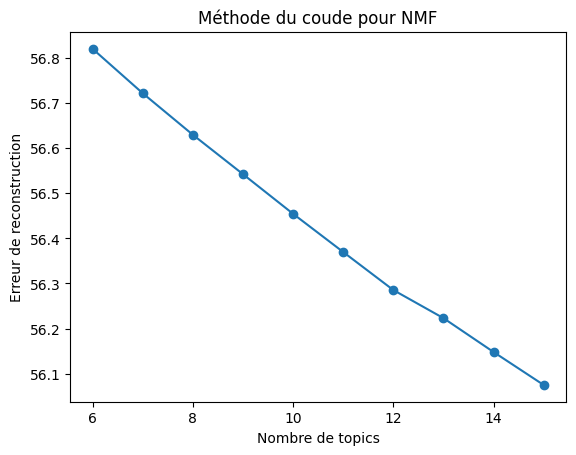

In [17]:
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt

ks = range(6, 16)
errors = []

for k in ks:
    nmf = NMF(n_components=k, random_state=42)
    nmf.fit(X)
    errors.append(nmf.reconstruction_err_)

plt.plot(list(ks), errors, marker='o')
plt.xlabel("Nombre de topics")
plt.ylabel("Erreur de reconstruction")
plt.title("Méthode du coude pour NMF")
plt.show()

# Choix de k = 8

In [21]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=8, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_


feature_names = vectorizer.get_feature_names_out()

def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")

afficher_topics(nmf, feature_names, 10)

Topic 1 : eau | grand | ciel | arbre | blanc | soleil | ombre | lumière | jour | bois
Topic 2 : monsieur | renée | cher | voix | femme | vrai | vou | homme | monde | abbé
Topic 3 : femme | amour | vie | homme | cœur | pensée | jeune | parole | âme | maîtresse
Topic 4 : sœur | lit | malade | salle | heure | interne | hôpital | médecin | jour | voix
Topic 5 : enfant | mère | petit | fille | père | fils | jeune | mme | bon | maison
Topic 6 : main | oeil | tête | petit | cheveu | bras | regard | corps | robe | pied
Topic 7 : homme | franc | argent | grand | journal | idée | chose | monde | bon | ami
Topic 8 : frère | cirque | exercice | pied | tour | jour | heure | saut | directeur | aîné


In [22]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_


feature_names = vectorizer.get_feature_names_out()

def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")

afficher_topics(nmf, feature_names, 10)

Topic 1 : eau | ciel | grand | arbre | blanc | soleil | bois | ombre | lumière | noir
Topic 2 : monsieur | renée | cher | voix | femme | vrai | vou | bon | homme | abbé
Topic 3 : femme | amour | vie | homme | cœur | pensée | parole | âme | maîtresse | corps
Topic 4 : heure | jour | matin | chambre | temps | nuit | rue | soir | maison | dîner
Topic 5 : enfant | mère | petit | mme | fils | pauvre | père | cœur | bon | famille
Topic 6 : main | oeil | tête | petit | cheveu | bras | regard | corps | pied | visage
Topic 7 : homme | franc | argent | journal | grand | monde | idée | art | livre | chose
Topic 8 : frère | cirque | exercice | tour | pied | saut | directeur | aîné | clown | chose
Topic 9 : fille | jeune | petit | père | maréchal | grand | mariage | monde | salon | année
Topic 10 : sœur | lit | malade | salle | interne | hôpital | médecin | voix | garde | rideau


In [23]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=12, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_


feature_names = vectorizer.get_feature_names_out()

def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")

afficher_topics(nmf, feature_names, 10)

Topic 1 : eau | ciel | arbre | blanc | grand | soleil | ombre | bois | lumière | noir
Topic 2 : monsieur | renée | cher | voix | vrai | vou | bon | abbé | maman | monde
Topic 3 : vie | pensée | cœur | mort | amour | âme | parole | chose | idée | jour
Topic 4 : heure | jour | rue | matin | chambre | maison | soir | temps | nuit | dîner
Topic 5 : enfant | mère | petit | fils | mme | pauvre | père | cœur | bon | famille
Topic 6 : femme | amour | homme | maîtresse | mari | amant | toilette | ménage | robe | jeune
Topic 7 : franc | cent | argent | pièce | bon | affaire | sou | fois | jeu | mois
Topic 8 : main | oeil | tête | petit | cheveu | bras | regard | pied | corps | coup
Topic 9 : fille | jeune | père | petit | maréchal | grand | mariage | monde | année | amie
Topic 10 : sœur | lit | malade | salle | interne | hôpital | médecin | voix | garde | rideau
Topic 11 : frère | cirque | exercice | tour | pied | saut | aîné | directeur | clown | chose
Topic 12 : homme | journal | grand | monde